# 04 — Moirai-1.1-R (Zero-Shot) for PV Power Forecasting

This notebook evaluates Moirai-1.1-R in a zero-shot setting for PV power forecasting. The experimental setup follows the same data preprocessing, train-test split, forecasting windows, and evaluation procedure used for Chronos-2 (`03_chronos_forecasting`), allowing the performance of the two foundation models to be compared under identical conditions.

The dataset is resampled to 15-minute intervals, converted from UTC to the `Europe/Zagreb` time zone, and divided into training and test sets using the same temporal split as the baseline models. The target variable is PV power (kWh per 15-minute interval), while weather variables are provided as dynamic future covariates (`feat_dynamic_real`). As in the other foundation model experiments, measured weather observations are assumed to be available throughout the forecasting horizon, following the proxy-for-perfect-weather-forecast assumption.

Forecasts are generated 24 hours ahead using non-overlapping windows with a context length of 512 time steps and a prediction horizon of 96 time steps, resulting in 213 evaluation windows over the period from `2020-01-01` to `2020-08-01`. Model performance is evaluated using the same metrics (`MAE`, `RMSE`, `R²`, and `nRMSE`) as the other forecasting models, and the results are appended to `../results/comparison.csv`.

For consistency with the other time-series foundation models, daytime performance is evaluated using a solar elevation threshold (`solar_elevation > 5°`). This differs slightly from the baseline notebooks, which define daytime using `power > 0`, although both approaches produce nearly identical evaluation periods.

> **Requirements:** `uni2ts` (`pip install uni2ts` or clone the SalesforceAIResearch/uni2ts repository). A GPU is recommended, particularly when using the larger Moirai models.

## 1. Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, os

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
from gluonts.dataset.common import ListDataset
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule   # pip install uni2ts

os.makedirs('../results', exist_ok=True)
os.makedirs('../figure',  exist_ok=True)

FIG_PREFIX = '04'
print('Libraries loaded ✓ | torch', torch.__version__, '| CUDA', torch.cuda.is_available())

/opt/anaconda3/envs/moirai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded ✓ | torch 2.4.1 | CUDA False


In [2]:
# ---- Benchmark configuration (IDENTICAL across every TSFM notebook) ----
SEED              = 321
CONTEXT_LENGTH    = 512          # past steps fed to the model   (5.33 days @ 15 min)
PREDICTION_LENGTH = 96           # forecast horizon              (24 h  @ 15 min)
STRIDE            = 96           # non-overlapping -> one 24h forecast per day
ELEV_THRESHOLD    = 5.0          # daytime filter: solar_elevation > 5 deg (HORIZON only)

TEST_START = pd.Timestamp('2020-01-01')
TEST_END   = pd.Timestamp('2020-08-01')

TARGET = 'power'
# measured weather = KNOWN-FUTURE covariates (proxy for a *perfect* weather forecast)
WEATHER_COVS = ['global_irradiance', 'direct_irradiance', 'diffuse_irradiance',
                'sun_zenith', 'sun_azimuth', 'temperature']
TIME_COVS    = ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']   # deterministic, known ahead
FUTURE_COVS  = WEATHER_COVS + TIME_COVS

np.random.seed(SEED)
print(f'context = {CONTEXT_LENGTH} ({CONTEXT_LENGTH*15/60/24:.2f} d) | '
      f'horizon = {PREDICTION_LENGTH} (24 h) | stride = {STRIDE}')
print(f'{len(FUTURE_COVS)} future covariates:', FUTURE_COVS)

context = 512 (5.33 d) | horizon = 96 (24 h) | stride = 96
10 future covariates: ['global_irradiance', 'direct_irradiance', 'diffuse_irradiance', 'sun_zenith', 'sun_azimuth', 'temperature', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']


## 2. Load dataset.csv

In [3]:
df_raw = pd.read_csv('../data/dataset.csv', index_col='timestamp', parse_dates=True)

# Same timezone handling as 02_baseline_forecasting: UTC -> Europe/Zagreb -> drop tz
local_tz = 'Europe/Zagreb'
df_raw.index = df_raw.index.tz_localize('UTC').tz_convert(local_tz).tz_localize(None)

print('raw:', df_raw.shape, '|', df_raw.index.min(), '->', df_raw.index.max())
df_raw.head(3)

raw: (2204759, 7) | 2018-04-17 07:24:00 -> 2023-03-04 23:54:00


,power,sun_zenith,sun_azimuth,temperature,global_irradiance,direct_irradiance,diffuse_irradiance
timestamp,,,,,,,
2018-04-17 07:24:00,0.00005,77.63,-92.47,14.1,7,0,7
2018-04-17 07:25:00,0.00005,77.46,-92.29,14.1,8,0,8
2018-04-17 07:26:00,0.00005,77.28,-92.12,14.1,8,0,8


## 3. Build the full regular 15-min grid

Night rows are kept (power = 0) so the model sees the daily cycle; the daytime filter is applied later, at evaluation, on the forecast horizon only.

In [4]:
# Resample to 15 min: power SUMMED (-> kWh per 15 min), weather AVERAGED  (same as baseline)
agg = {'power': 'sum', 'sun_zenith': 'mean', 'sun_azimuth': 'mean', 'temperature': 'mean',
       'global_irradiance': 'mean', 'direct_irradiance': 'mean', 'diffuse_irradiance': 'mean'}
df = df_raw.resample('15min', closed='left', label='left').agg(agg)

# KEY DIFFERENCE vs baseline: the baseline drops nighttime (power>0), which breaks the
# regular grid TSFMs require. Instead we keep the FULL, evenly-spaced 15-min grid so the
# model sees the diurnal cycle, and set night power to 0 (no sun -> no output).
full_idx = pd.date_range(df.index.min(), df.index.max(), freq='15min')
df = df.reindex(full_idx)
df.index.name = 'timestamp'

df['power'] = df['power'].fillna(0.0).clip(lower=0)
irr = ['global_irradiance', 'direct_irradiance', 'diffuse_irradiance']
df[irr] = df[irr].clip(lower=0)
df[WEATHER_COVS] = df[WEATHER_COVS].interpolate(limit_direction='both')

# Solar elevation for the daytime filter (dataset has sun_zenith; elevation = 90 - zenith)
df['solar_elevation'] = 90.0 - df['sun_zenith']

# Deterministic time covariates (known for the future horizon)
_h = df.index.hour + df.index.minute / 60.0
_d = df.index.dayofyear
df['hour_sin'] = np.sin(2*np.pi*_h/24.0); df['hour_cos'] = np.cos(2*np.pi*_h/24.0)
df['doy_sin']  = np.sin(2*np.pi*_d/366.0); df['doy_cos'] = np.cos(2*np.pi*_d/366.0)

assert not df[FUTURE_COVS + ['power', 'solar_elevation']].isna().any().any(), 'NaNs remain'
print('full grid:', df.shape, '| night filled with 0, no NaNs')
df.head(3)

full grid: (171139, 12) | night filled with 0, no NaNs


,power,sun_zenith,sun_azimuth,temperature,global_irradiance,direct_irradiance,diffuse_irradiance,solar_elevation,hour_sin,hour_cos,doy_sin,doy_cos
timestamp,,,,,,,,,,,,
2018-04-17 07:15:00,0.000283,77.195000,-92.026667,14.100000,9.000000,0.0,9.0,12.805000,0.946930,-0.321439,0.964806,-0.262962
2018-04-17 07:30:00,0.003250,75.363333,-90.153333,14.200000,20.866667,0.0,20.8,14.636667,0.923880,-0.382683,0.964806,-0.262962
2018-04-17 07:45:00,0.018767,72.747333,-87.450000,14.446667,49.800000,0.0,49.8,17.252667,0.896873,-0.442289,0.964806,-0.262962


## 4. Rolling-window layout + metric helper

In [5]:
# Rolling-window layout (identical for every model):
#
#   context window           |  prediction horizon
#   [i-512 ----------- i)     |  [i ------------ i+96)
#        512 steps (5.3 d)    |     96 steps (24 h)
#                            (i = forecast origin, local midnight)
#
# stride = 96  -> non-overlapping, exactly one calendar day forward per window.
idx = df.index
o0, oN = idx.get_loc(TEST_START), idx.get_loc(TEST_END)
origins = list(range(o0, oN, STRIDE))

assert origins[0] - CONTEXT_LENGTH >= 0, 'not enough history before the first origin'
print(f'{len(origins)} forecast windows (2020-01-01 -> 2020-08-01)')
print(f'first origin : {idx[origins[0]]}  (context back to {idx[origins[0]-CONTEXT_LENGTH]})')
print(f'last  origin : {idx[origins[-1]]}  (horizon ends {idx[origins[-1]+PREDICTION_LENGTH-1]})')

213 forecast windows (2020-01-01 -> 2020-08-01)
first origin : 2020-01-01 00:00:00  (context back to 2019-12-26 16:00:00)
last  origin : 2020-07-31 00:00:00  (horizon ends 2020-07-31 23:45:00)


In [6]:
def evaluate(name, y_true, y_pred, fig_prefix=FIG_PREFIX):
    """MAE / RMSE / R2 / nRMSE + figures -- same conventions as 02_baseline_forecasting.
    nRMSE denominator = y_true.max() (identical actuals across models -> identical scale)."""
    y_pred = np.clip(y_pred, 0, None)
    y_true = np.asarray(y_true)

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    nrmse = rmse / y_true.max()

    print(f'\n[{name}]')
    print(f'  MAE   = {mae:.4f} kWh')
    print(f'  RMSE  = {rmse:.4f} kWh')
    print(f'  R2    = {r2:.4f}')
    print(f'  nRMSE = {nrmse:.4f}')

    slug = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    lim = max(float(y_true.max()), float(y_pred.max())) * 1.05
    axes[0].scatter(y_true, y_pred, s=4, alpha=0.3)
    axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1)
    axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
    axes[0].set_xlabel('Actual [kWh]'); axes[0].set_ylabel('Predicted [kWh]')
    axes[0].set_title(f'{name}: Predicted vs Actual'); axes[0].grid(True)

    week = 7 * 24 * 4
    axes[1].plot(y_true[-week:], label='Actual')
    axes[1].plot(y_pred[-week:], label='Predicted')
    axes[1].set_title(f'{name}: last ~week of test samples')
    axes[1].set_ylabel('kWh'); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    fname = f'../figure/{fig_prefix}_{slug}_eval.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
    print('Saved ->', fname)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'nRMSE': nrmse}

## 5. Load Moirai

In [7]:
MODEL_NAME  = 'Moirai-1.1-R (zero-shot)'
MODEL_KEY   = 'moirai'
MOIRAI_SIZE = 'base'      # 'small' | 'base' | 'large'  (start small on CPU)
PATCH_SIZE  = 'auto'       # 'auto' | 8 | 16 | 32 | 64 | 128
NUM_SAMPLES = 100          # probabilistic samples -> we take the mean as the point forecast
FREQ        = '15min'

module = MoiraiModule.from_pretrained(f'Salesforce/moirai-1.1-R-{MOIRAI_SIZE}')
model  = MoiraiForecast(module=module,
                        prediction_length=PREDICTION_LENGTH,
                        context_length=CONTEXT_LENGTH,
                        patch_size=PATCH_SIZE,
                        num_samples=NUM_SAMPLES,
                        target_dim=1,
                        feat_dynamic_real_dim=len(FUTURE_COVS),   # known-future covariates
                        past_feat_dynamic_real_dim=0)
predictor = model.create_predictor(batch_size=1)
print('Moirai loaded:', MOIRAI_SIZE, '| covariates:', len(FUTURE_COVS))

Moirai loaded: base | covariates: 10


## 6. Rolling 24h-ahead forecast

For each window we build a GluonTS series: `target` = 512 past `power` values, and
`feat_dynamic_real` = the weather + time covariates spanning **context + horizon**
(608 steps) — this is how Moirai receives known-future covariates. The point forecast is
the mean of the sampled paths; each call is timed for the cost summary.

In [8]:
power_arr = df['power'].values
cov_arr   = df[FUTURE_COVS].values                 # (T, n_feat)

win_preds, win_acts, win_ts, win_infer = [], [], [], []

for k, i in enumerate(origins):
    target = power_arr[i - CONTEXT_LENGTH:i]                        # (512,)
    feat   = cov_arr[i - CONTEXT_LENGTH:i + PREDICTION_LENGTH].T    # (n_feat, 608)

    ds = ListDataset([{'start': pd.Period(df.index[i - CONTEXT_LENGTH], freq=FREQ),
                       'target': target,
                       'feat_dynamic_real': feat}], freq=FREQ)

    t0 = time.time()
    fc = next(iter(predictor.predict(ds)))
    win_infer.append(time.time() - t0)

    win_preds.append(np.asarray(fc.mean, dtype=float))             # (96,)
    win_acts.append(power_arr[i:i + PREDICTION_LENGTH])
    win_ts.append(df.index[i:i + PREDICTION_LENGTH])
    if (k + 1) % 25 == 0:
        print(f'  {k + 1}/{len(origins)} windows')

print('Done:', len(origins), 'forecasts')

  25/213 windows
  50/213 windows
  75/213 windows
  100/213 windows
  125/213 windows
  150/213 windows
  175/213 windows
  200/213 windows
Done: 213 forecasts


## 7. Assemble forecasts, apply daytime filter, score

20448 horizon steps | 10109 daytime (49.4%)

[Moirai-1.1-R (zero-shot)]
  MAE   = 0.1889 kWh
  RMSE  = 0.2488 kWh
  R2    = -0.2003
  nRMSE = 0.2895


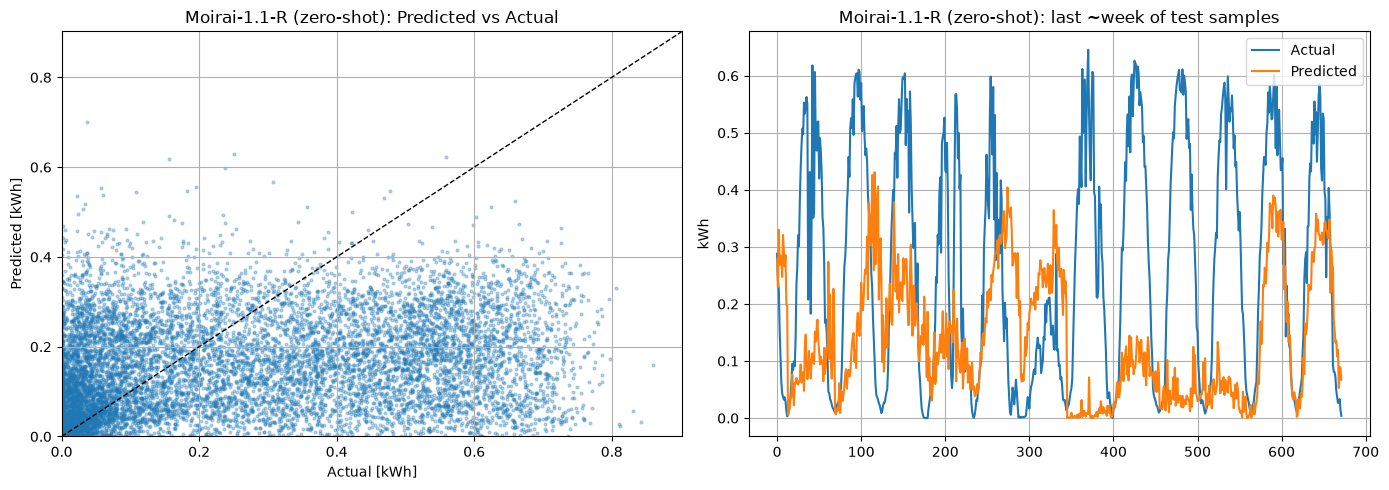

Saved -> ../figure/04_moirai-1.1-r_zero-shot_eval.png

[Moirai-1.1-R (zero-shot) (all-hours)]
  MAE   = 0.1290 kWh
  RMSE  = 0.1913 kWh
  R2    = 0.1465
  nRMSE = 0.2226


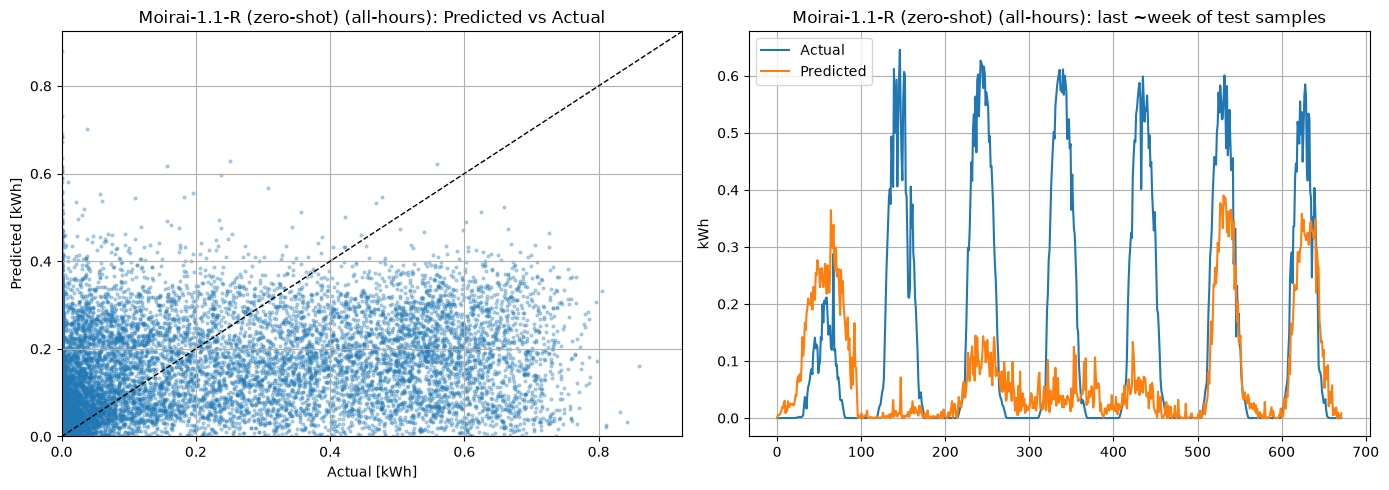

Saved -> ../figure/04_moirai-1.1-r_zero-shot_all-hours_eval.png


In [9]:
# Stack every 24h horizon in chronological order
y_pred_full = np.concatenate(win_preds)                    # (n_windows * 96,)
y_true_full = np.concatenate(win_acts)
ts_full     = pd.DatetimeIndex(np.concatenate([t.values for t in win_ts]))

# Daytime filter applied to the PREDICTION timestamps only (context may contain night)
day_mask = df['solar_elevation'].reindex(ts_full).values > ELEV_THRESHOLD
print(f'{len(y_true_full)} horizon steps | {int(day_mask.sum())} daytime ({day_mask.mean():.1%})')

# ---- Headline (daytime) metrics: same evaluation set the baseline is scored on ----
res = evaluate(MODEL_NAME, y_true_full[day_mask], y_pred_full[day_mask])

# ---- All-hours metrics for completeness (brief asks for these too) ----
_ = evaluate(MODEL_NAME + ' (all-hours)', y_true_full, y_pred_full)

## 8. Save results (predictions + comparison.csv row)

In [10]:
# ---- Inference cost (per 24h forecast) ----
total_infer = float(np.sum(win_infer))
per24       = total_infer / len(origins)
res['Train Time']     = 0.0                # zero-shot: no training
res['Inference Time'] = total_infer
print(f'Inference: {total_infer:.1f}s total over {len(origins)} windows '
      f'-> {per24:.3f}s per 24h forecast')

# ---- Save per-step predictions (full horizon, both night & day) ----
pd.DataFrame({'timestamp': ts_full,
              'actual':    y_true_full,
              MODEL_KEY:   np.clip(y_pred_full, 0, None),
              'is_daytime': day_mask}).to_pickle(f'../results/{MODEL_KEY}_predictions.pkl')
print(f'Saved -> ../results/{MODEL_KEY}_predictions.pkl')

# ---- Append the headline row to the shared comparison.csv (same schema as baseline) ----
comp_path = '../results/comparison.csv'
comp_cols = ['Model', 'MAE', 'RMSE', 'nRMSE', 'Train Time', 'Inference Time']
new_rows  = pd.DataFrame([{k: res[k] for k in comp_cols}])

if os.path.exists(comp_path):
    existing = pd.read_csv(comp_path)
    existing = existing[~existing['Model'].isin(new_rows['Model'])]
    combined = pd.concat([existing, new_rows], ignore_index=True)
else:
    combined = new_rows
combined[comp_cols].to_csv(comp_path, index=False)

print(f'Saved -> {comp_path}\n')
print(combined[comp_cols].to_string(index=False))

Inference: 1053.7s total over 213 windows -> 4.947s per 24h forecast
Saved -> ../results/moirai_predictions.pkl
Saved -> ../results/comparison.csv

                   Model      MAE     RMSE    nRMSE  Train Time  Inference Time
                LightGBM 0.021175 0.034823 0.040512    0.776353        0.014204
        LightGBM (tuned) 0.020895 0.034539 0.040182   48.507317        0.033761
                     MLP 0.020945 0.034464 0.040095    3.505997        0.009781
   Chronos-2 (zero-shot) 0.030790 0.061026 0.070997    0.000000       27.479502
Moirai-1.1-R (zero-shot) 0.188942 0.248844 0.289499    0.000000     1053.703917


---
**Outputs**: `../figure/04_*_eval.png`, `../results/moirai_predictions.pkl`, and a headline row appended to `../results/comparison.csv` so this model stacks directly against LightGBM / MLP (and the other TSFM notebook).